VINOD KUMAR K V

Building a SimpleRNN Model for Weather Temperature Prediction

Objective

The goal of this assignment is to design, implement, and evaluate a Recurrent Neural Network

(RNN) model (using SimpleRNN) to forecast the next day’s temperature based on past weather

data.

Dataset

Use the Daily Weather Dataset

● Example: Daily Weather Dataset – Kaggle

● Key Features:

○ Date

○ Temperature (target variable)

○ Humidity

○ Wind Speed

○ Pressure (optional)

Tasks

Part A: Data Understanding and Preprocessing

Load the dataset and explore:
○ Display first 10 rows.

○ Plot temperature trends over time.

○ Check for missing values.

Preprocess the data:
○ Handle missing values (impute/remove).

○ Normalize values using MinMaxScaler (so RNN converges faster).

○ Create input sequences:

■ Use past 7–14 days’ weather data (temperature, humidity, wind speed) as input.

■ Target: next day’s temperature.

○ Split dataset into train, validation, and test sets.

Part B: RNN Model Development

Build a SimpleRNN model using TensorFlow/Keras:
○ Input layer (with shape = sequence length × number of features).

○ SimpleRNN layer (e.g., 32–64 units).

○ Dropout layer (optional, to avoid overfitting).

○ Dense layer with 1 unit (linear activation for regression).

Compile the model:
○ Loss: Mean Squared Error (MSE).

○ Optimizer: Adam.

○ Metrics: Mean Absolute Error (MAE).

Train the model on training data:
○ Batch size: 32

○ Epochs: 50–100

○ Use validation data to monitor performance.

○ Plot training vs validation loss curves.

Part C: Model Evaluation & Forecasting

Evaluate the model on the test set:
○ Calculate RMSE, MAE, and R² score.

○ Plot predicted vs actual temperatures for the test period.

Forecast the next 7 days of temperature using the trained model and visualize
predictions vs recent historical data.

https://www.kaggle.com/datasets/muthuj7/weather-dataset

Part A: Data Understanding and Preprocessing

 Load the dataset and explore:

○ Display first 10 rows.

○ Plot temperature trends over time.

○ Check for missing values

In [ ]:
#Data Acquisition

import pandas as pd
df = pd.read_csv("weatherHistory.csv")
df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


IMPORT LIBRARIES

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# Model Building
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# Model Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# Convert date column
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)

# Set as Index
df.set_index("Formatted Date", inplace=True)

# Sort by Date
df = df.sort_values('Formatted Date')

In [ ]:
# Display First 10 Rows
df.head(10)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


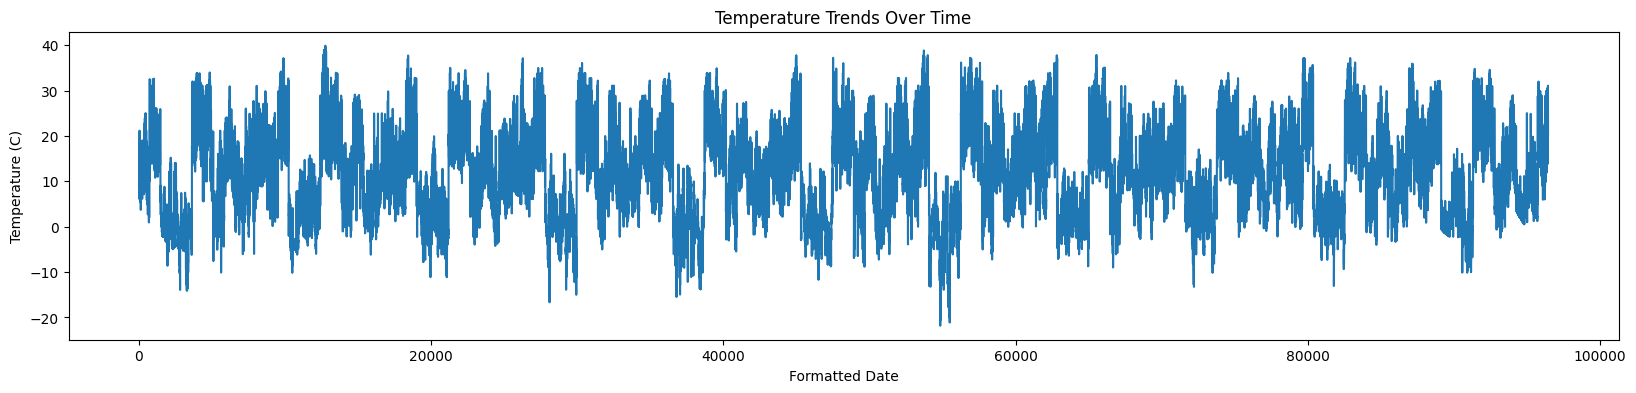

In [ ]:
# Plot temperature over time
import matplotlib.pyplot as plt
plt.figure(figsize=(20,4))
plt.plot(df.index, df['Temperature (C)'])
plt.title("Temperature Trends Over Time")
plt.xlabel("Formatted Date")
plt.ylabel("Temperature (C)")
plt.show()

In [ ]:
# Show Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [ ]:
# Check Missing Values
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


Preprocess the data:

○ Handle missing values (impute/remove).

○ Normalize values using MinMaxScaler (so RNN converges faster).

○ Create input sequences:

■ Use past 7–14 days’ weather data (temperature, humidity, wind speed) as input.

■ Target: next day’s temperature.

○ Split dataset into train, validation, and test sets.



In [ ]:
df["Precip Type"].value_counts()

,count
Precip Type,
rain,85224
snow,10712


In [ ]:
# Handle Missing Values
df = df.dropna(subset=["Precip Type"])

In [ ]:
print("Number of Duplicated Values: ", df.duplicated().sum())

Number of Duplicated Values:  24


In [ ]:
df = df.drop_duplicates()
print("Number of Duplicated Values After Cleaning: ", df.duplicated().sum())

Number of Duplicated Values After Cleaning:  0


NORMALIZE THE DATA

In [ ]:
data = df[["Temperature (C)", "Humidity", "Wind Speed (km/h)", "Pressure (millibars)"]]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

CREATE INPUT SEEQUENCE

In [ ]:
# Create Input Sequences
import numpy as np
def create_sequences(data, time_steps):
    X, y = [], []

    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps, 0])

    return np.array(X), np.array(y)

TIME_STEPS = 14

X, y = create_sequences(scaled_data, TIME_STEPS)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (95898, 14, 4)
y shape: (95898,)


TRAIN, TEST,  SPLIT

In [ ]:
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.10)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

Part B: RNN Model Development

Build a SimpleRNN model using TensorFlow/Keras:
○ Input layer (with shape = sequence length × number of features).

○ SimpleRNN layer (e.g., 32–64 units).

○ Dropout layer (optional, to avoid overfitting).

○ Dense layer with 1 unit (linear activation for regression).

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(TIME_STEPS, X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#COMPILE MODEL

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

Train the model on training data:

○ Batch size: 32

○ Epochs: 50–100

○ Use validation data to monitor performance.

○ Plot training vs validation loss curves.



In [ ]:
#TRAIN THE MODEL ON TRAINING DATA

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32
)

Epoch 1/100
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 6.6269e-04 - mae: 0.0177 - val_loss: 3.7412e-04 - val_mae: 0.0135
Epoch 2/100
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 6.6190e-04 - mae: 0.0177 - val_loss: 3.8128e-04 - val_mae: 0.0130
Epoch 3/100
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 6.5400e-04 - mae: 0.0177 - val_loss: 3.7787e-04 - val_mae: 0.0128
Epoch 4/100
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 6.6182e-04 - mae: 0.0177 - val_loss: 3.8273e-04 - val_mae: 0.0135
Epoch 5/100
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 6.6400e-04 - mae: 0.0178 - val_loss: 3.6215e-04 - val_mae: 0.0125
Epoch 6/100
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 6.6108e-04 - mae: 0.0177 - val_loss: 3.5882e-04 - val_mae: 0.0124
Epoch 7/100
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 6.6568e-04 - mae: 0.0178 - val_loss: 3.5242e-04 - val_mae: 0.0127
Epoch 8/100
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 6.6185e-04 - mae: 0.0177 -

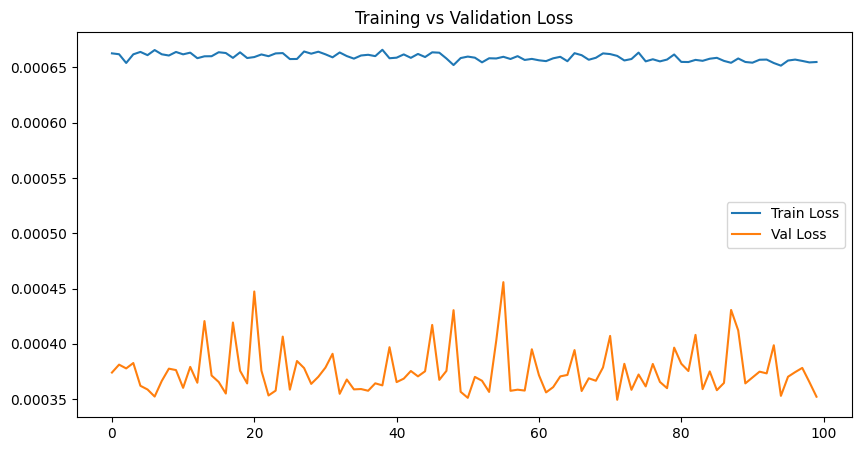

In [ ]:
#PLOT TRAINING VS VALIDATION LOSS CURVES

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

MODEL EVALUATION AND FORECASTING

Evaluate the model on the test set:

○ Calculate RMSE, MAE, and R² score.

○ Plot predicted vs actual temperatures for the test period.





In [ ]:
# CALCULATE RMSE, MAE, and R² SCORE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred);
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
RMSE: 0.01814556086897253
MAE: 0.011646206018019335
R²: 0.9844560742381717


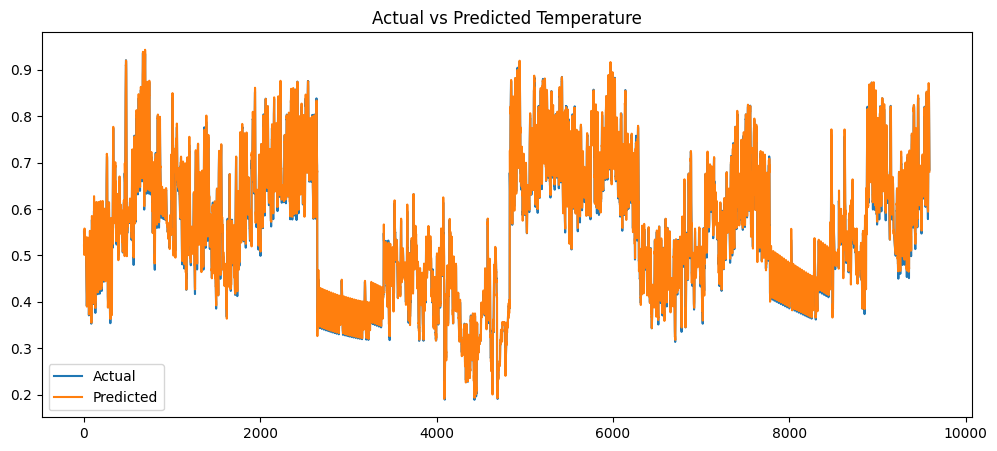

In [ ]:
# PLOT PREDICTED vs ACTUAL TEMPERATURE
plt.figure(figsize=(12,5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Temperature")
plt.show()

In [ ]:
# Forecast next 7 days
last_sequence = scaled_data[-TIME_STEPS:]
forecast = []
current_batch = last_sequence.reshape((1, TIME_STEPS, data.shape[1]))

for i in range(7):
    # Predict next step
    next_pred = model.predict(current_batch, verbose=0)[0]
    forecast.append(next_pred[0])

    new_features = last_sequence[-1, 1:]
    new_row = np.insert(new_features, 0, next_pred[0])

    # Update the batch: Slide window forward
    new_row_reshaped = new_row.reshape(1, 1, data.shape[1])
    current_batch = np.append(current_batch[:, 1:, :], new_row_reshaped, axis=1)

# Rescaling Logic
forecast_array = np.array(forecast).reshape(-1, 1)

# Create a dummy array with the same width as the original training data
dummy_for_rescaling = np.zeros((len(forecast_array), data.shape[1]))
dummy_for_rescaling[:, 0] = forecast_array.flatten()

# Inverse transform and extract the temperature column (index 0)
forecast_rescaled_full = scaler.inverse_transform(dummy_for_rescaling)
forecast_rescaled_temperature = forecast_rescaled_full[:, 0]

print("7-Day Forecast (Temperature):")
seven_d_forecast = [f"{temp:.2f}°C" for temp in forecast_rescaled_temperature]
print(seven_d_forecast)

7-Day Forecast (Temperature):
['19.41°C', '18.74°C', '18.14°C', '17.74°C', '17.48°C', '17.49°C', '17.86°C']


Forecast the next 7 days of temperature using the trained model and visualize
predictions vs recent historical data.

In [ ]:
# Next 7 Days of Temperture
print("\n7-DAY TEMPERATURE FORECAST")
print("-" *22)
for day, temp in enumerate(forecast_rescaled_temperature, 1):
    print(f"Day {day}: {temp:.2f}°")


7-DAY TEMPERATURE FORECAST
----------------------
Day 1: 19.41°
Day 2: 18.74°
Day 3: 18.14°
Day 4: 17.74°
Day 5: 17.48°
Day 6: 17.49°
Day 7: 17.86°


Temperature using the trained model and visualize predictions vs recent historical data

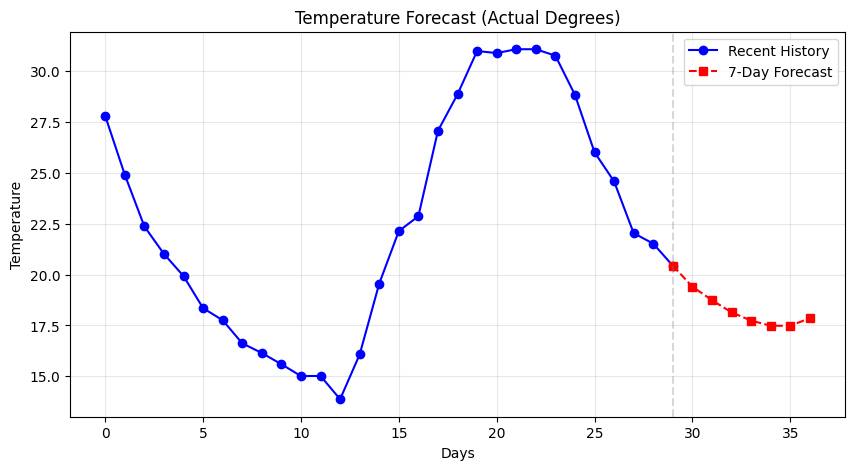

In [ ]:
#VISUALISE PREDICTIONS VS RECENT HISTORICAL DATA

# Define y_test_rescaled by inverse transforming y_test
y_test_reshaped = y_test.reshape(-1, 1)
dummy_for_y_test_rescaling = np.zeros((len(y_test_reshaped), data.shape[1]))
dummy_for_y_test_rescaling[:, 0] = y_test_reshaped.flatten()
y_test_rescaled = scaler.inverse_transform(dummy_for_y_test_rescaling)[:, 0]

history_slice = y_test_rescaled[-30:]
forecast_data = forecast_rescaled_temperature

# 2. Create the "Bridge"
bridge_forecast = np.append(history_slice[-1], forecast_data)

# 3. Define X-axis ranges
history_range = range(len(history_slice))
forecast_range = range(len(history_slice) - 1, len(history_slice) + 7)

plt.figure(figsize=(10, 5))

# Plot History
plt.plot(history_range, history_slice, label="Recent History", color="blue", marker='o')

# Plot Forecast (Starting from the last historical point)
plt.plot(forecast_range, bridge_forecast, label="7-Day Forecast", color="red", linestyle="--", marker='s')

plt.axvline(x=len(history_slice)-1, color='gray', alpha=0.3, linestyle='--')
plt.legend()
plt.title("Temperature Forecast (Actual Degrees)")
plt.xlabel("Days")
plt.ylabel("Temperature")
plt.grid(True, alpha=0.3)
plt.show()